imported and checked data for missing values first

In [4]:
import pandas as pd
import numpy as np

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print()
print("Missing values in train:")
print(train.isnull().sum())
print()
print("Target distribution:")
print(train['Irrigation_Need'].value_counts())
print()
print("Column types:")
print(train.dtypes)

Train shape: (630000, 21)
Test shape: (270000, 20)

Missing values in train:
id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

Target distribution:
Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

Column types:
id                           int64
Soil_Type                      str
Soil_pH                    float64
Soil_Moisture              float64
Organic_Carbon             floa

separated training and testing data

In [5]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

X = train.drop(columns=['id', 'Irrigation_Need'])
y = train['Irrigation_Need']
X_test = test.drop(columns=['id'])

le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

cat_cols = X.select_dtypes(include=['object', 'string']).columns

X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)


enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train[cat_cols] = enc.fit_transform(X_train[cat_cols])
X_val[cat_cols] = enc.transform(X_val[cat_cols])
X_test[cat_cols] = enc.transform(X_test[cat_cols])


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
X_scaled = np.vstack([X_train, X_val])
y_encoded = np.concatenate([y_train, y_val])
print("Train size:", X_train.shape)
print("Val size:", X_val.shape)

Train size: (504000, 19)
Val size: (126000, 19)


naive bayes

Naive Bayes Accuracy: 0.8257539682539683

Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.41      0.52      4249
           1       0.85      0.90      0.88     73737
           2       0.79      0.75      0.77     48014

    accuracy                           0.83    126000
   macro avg       0.78      0.69      0.72    126000
weighted avg       0.82      0.83      0.82    126000



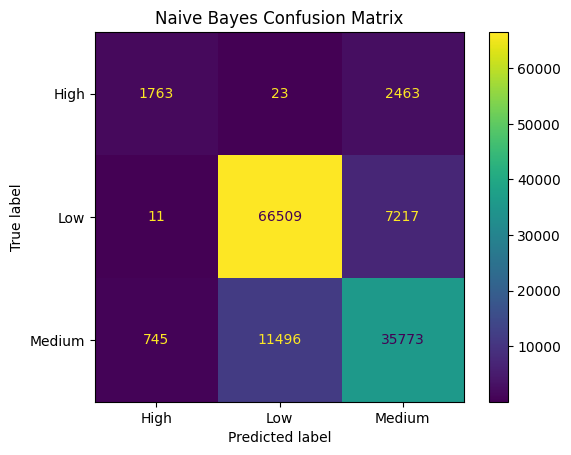

In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay,classification_report
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_val)

acc_nb = accuracy_score(y_val, y_pred_nb)
print("Naive Bayes Accuracy:", acc_nb)

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred_nb))

cm = confusion_matrix(y_val, y_pred_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot()
plt.title("Naive Bayes Confusion Matrix")
plt.show()

decision tree

Decision Tree Accuracy: 0.9848095238095238

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.91      0.93      4249
           1       0.99      1.00      0.99     73737
           2       0.99      0.97      0.98     48014

    accuracy                           0.98    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.98      0.98      0.98    126000



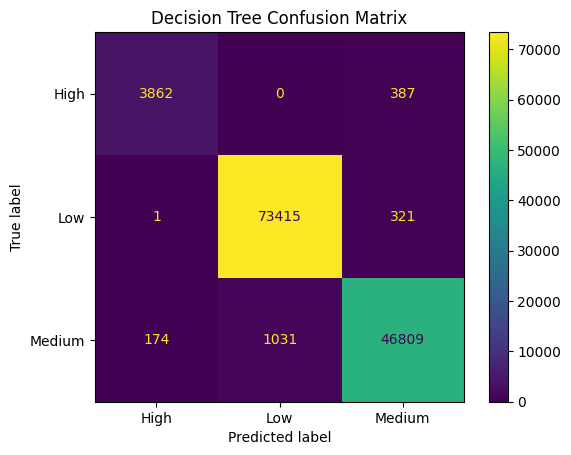

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay,classification_report
import matplotlib.pyplot as plt

dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_val)

acc_dt = accuracy_score(y_val, y_pred_dt)
print("Decision Tree Accuracy:", acc_dt)

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred_dt))

cm = confusion_matrix(y_val, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

random forest

Random Forest Accuracy: 0.9851507936507936

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.91      0.93      4249
           1       0.99      1.00      0.99     73737
           2       0.99      0.98      0.98     48014

    accuracy                           0.99    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.99      0.99      0.99    126000



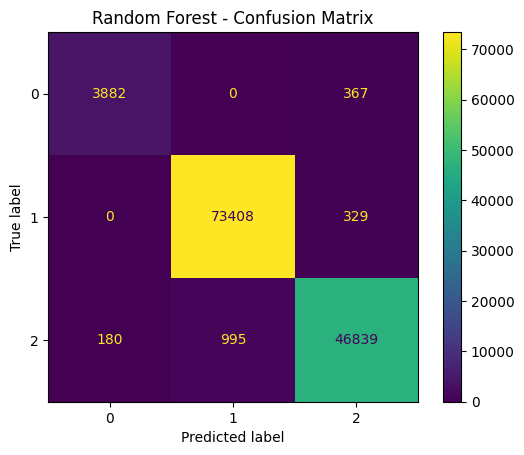

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)
acc_rf = accuracy_score(y_val, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred_rf))

cm = confusion_matrix(y_val, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

logistic regression

Logistic Regression Accuracy: 0.7489206349206349

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.36      0.47      4249
           1       0.79      0.84      0.81     73737
           2       0.68      0.65      0.66     48014

    accuracy                           0.75    126000
   macro avg       0.72      0.62      0.65    126000
weighted avg       0.75      0.75      0.74    126000



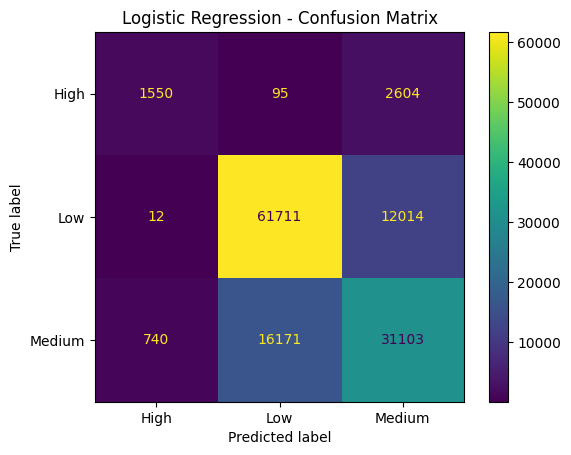

In [8]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_val)

acc_lr = accuracy_score(y_val, y_pred_lr)
print("Logistic Regression Accuracy:", acc_lr)

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred_lr))

cm = confusion_matrix(y_val, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

k-means as classifier

K-Means (as classifier) Accuracy: 0.605484126984127

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      4249
           1       0.66      0.75      0.70     73737
           2       0.50      0.44      0.47     48014

    accuracy                           0.61    126000
   macro avg       0.39      0.40      0.39    126000
weighted avg       0.58      0.61      0.59    126000



C:\Users\PMLS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PMLS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PMLS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classif

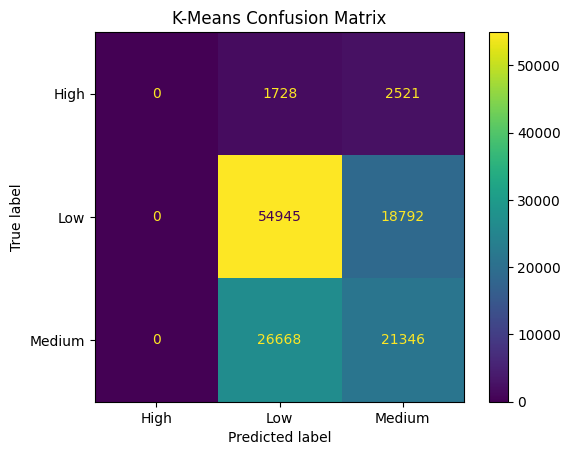

In [9]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_train)

train_clusters = kmeans.labels_
cluster_label_map = {}
for cluster in range(3):
    mask = train_clusters == cluster
    majority = np.bincount(y_train[mask]).argmax()
    cluster_label_map[cluster] = majority

val_clusters = kmeans.predict(X_val)
y_pred_km = np.array([cluster_label_map[c] for c in val_clusters])

acc_km = accuracy_score(y_val, y_pred_km)
print("K-Means (as classifier) Accuracy:", acc_km)

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred_km))

cm = confusion_matrix(y_val, y_pred_km)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot()
plt.title("K-Means Confusion Matrix")
plt.show()

K fold accuracy and std dev

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    DecisionTreeClassifier(max_depth=10, random_state=42),
    X_scaled, y_encoded,
    cv=kf,
    scoring='accuracy'
)
print("K-Fold CV Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Std Dev:", scores.std())

K-Fold CV Scores: [0.985      0.98485714 0.98447619 0.9850873  0.98419841]
Mean Accuracy: 0.9847238095238096
Std Dev: 0.00033572085250060626


LOOCV

In [12]:
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

X_sample = X_scaled[:200]
y_sample = y_encoded[:200]

loo = LeaveOneOut()
loo_scores = cross_val_score(
    DecisionTreeClassifier(max_depth=10, random_state=42),
    X_sample, y_sample,
    cv=loo,
    scoring='accuracy'
)

print("LOOCV Accuracy (on 200 samples):", loo_scores.mean())

LOOCV Accuracy (on 200 samples): 0.795


In [14]:
results = {
    'Model': ['Decision Tree', 'Naive Bayes', 'K-Means', 'Logistic Regression', 'Random Forest'],
    'Validation Accuracy': [acc_dt, acc_nb, acc_km, acc_lr, acc_rf]
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Validation Accuracy', ascending=False)
print(results_df.to_string(index=False))

              Model  Validation Accuracy
      Random Forest             0.985151
      Decision Tree             0.984810
        Naive Bayes             0.825754
Logistic Regression             0.748921
            K-Means             0.605484


final summary

In [6]:
from sklearn.tree import DecisionTreeClassifier
final_model = DecisionTreeClassifier(max_depth=15, random_state=42)
final_model.fit(X_scaled, y_encoded)

test_preds = final_model.predict(X_test_scaled)
test_preds_labels = le_target.inverse_transform(test_preds)


submission = pd.DataFrame({
    'id': test['id'],
    'Irrigation_Need': test_preds_labels
})

submission.to_csv("submission.csv", index=False)
print("Submission saved")
print(submission.head())
print(submission['Irrigation_Need'].value_counts())

Submission saved
       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low
Irrigation_Need
Low       159731
Medium    101370
High        8899
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

from sklearn.ensemble import RandomForestClassifier

# Load data
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# Split features/target
X = train.drop(columns=['id', 'Irrigation_Need'])
y = train['Irrigation_Need']
X_test = test.drop(columns=['id'])

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Identify column types
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

# Model
rf = RandomForestClassifier(random_state=42)

# Pipeline
pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', rf)
])

# Hyperparameter tuning
param_grid = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Train
grid.fit(X, y_encoded)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

# Predict
best_model = grid.best_estimator_
test_preds = best_model.predict(X_test)

# Decode labels
test_preds_labels = le.inverse_transform(test_preds)

# Submission
submission = pd.DataFrame({
    'id': test['id'],
    'Irrigation_Need': test_preds_labels
})

submission.to_csv("submission.csv", index=False)

print("Submission saved!")
print(submission.head())